In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from matplotlib.pyplot import legend
from numpy.ma.extras import column_stack

In [23]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
dry_bean = fetch_ucirepo(id=602)

# data (as pandas dataframes)
X = dry_bean.data.features
y = dry_bean.data.targets


# Объединяем X и y в один DataFrame
df = X.copy()
df['class'] = y



## 📊 B.P3 – Exploratory Data Analysis (EDA)

To begin our AI project, we performed an exploratory data analysis (EDA) to understand the structure, scale, and content of the dataset. The Dry Bean dataset consists of 13,611 samples and 17 columns, including 16 numerical features and one categorical label (`class`). There are no missing values.

Below we present three key summaries side by side:
- First 5 rows of the dataset
- Descriptive statistics for numerical features
- Data types and non-null count for each column

In [24]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRatio      13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  Roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  class            13611 non-null  object 
dtypes: float64(1

The Dry Bean dataset contains a total of **13,611 rows** and **17 columns**. After inspecting the dataset using `.info()`, we can confirm that **none of the columns contain missing values** — all entries across the entire dataset are complete. This ensures that **no imputation or removal of missing data** is necessary during preprocessing.

In [26]:
df

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13606,42097,759.696,288.721612,185.944705,1.552728,0.765002,42508,231.515799,0.714574,0.990331,0.916603,0.801865,0.006858,0.001749,0.642988,0.998385,DERMASON
13607,42101,757.499,281.576392,190.713136,1.476439,0.735702,42494,231.526798,0.799943,0.990752,0.922015,0.822252,0.006688,0.001886,0.676099,0.998219,DERMASON
13608,42139,759.321,281.539928,191.187979,1.472582,0.734065,42569,231.631261,0.729932,0.989899,0.918424,0.822730,0.006681,0.001888,0.676884,0.996767,DERMASON
13609,42147,763.779,283.382636,190.275731,1.489326,0.741055,42667,231.653247,0.705389,0.987813,0.907906,0.817457,0.006724,0.001852,0.668237,0.995222,DERMASON


We generated histograms for all numerical features (except the target `class`) to explore their distributions. This helped identify skewness, outliers, and the general shape of the data. Several features such as `Area` and `Perimeter` are right-skewed, indicating potential benefit from scaling or transformation in later modeling.

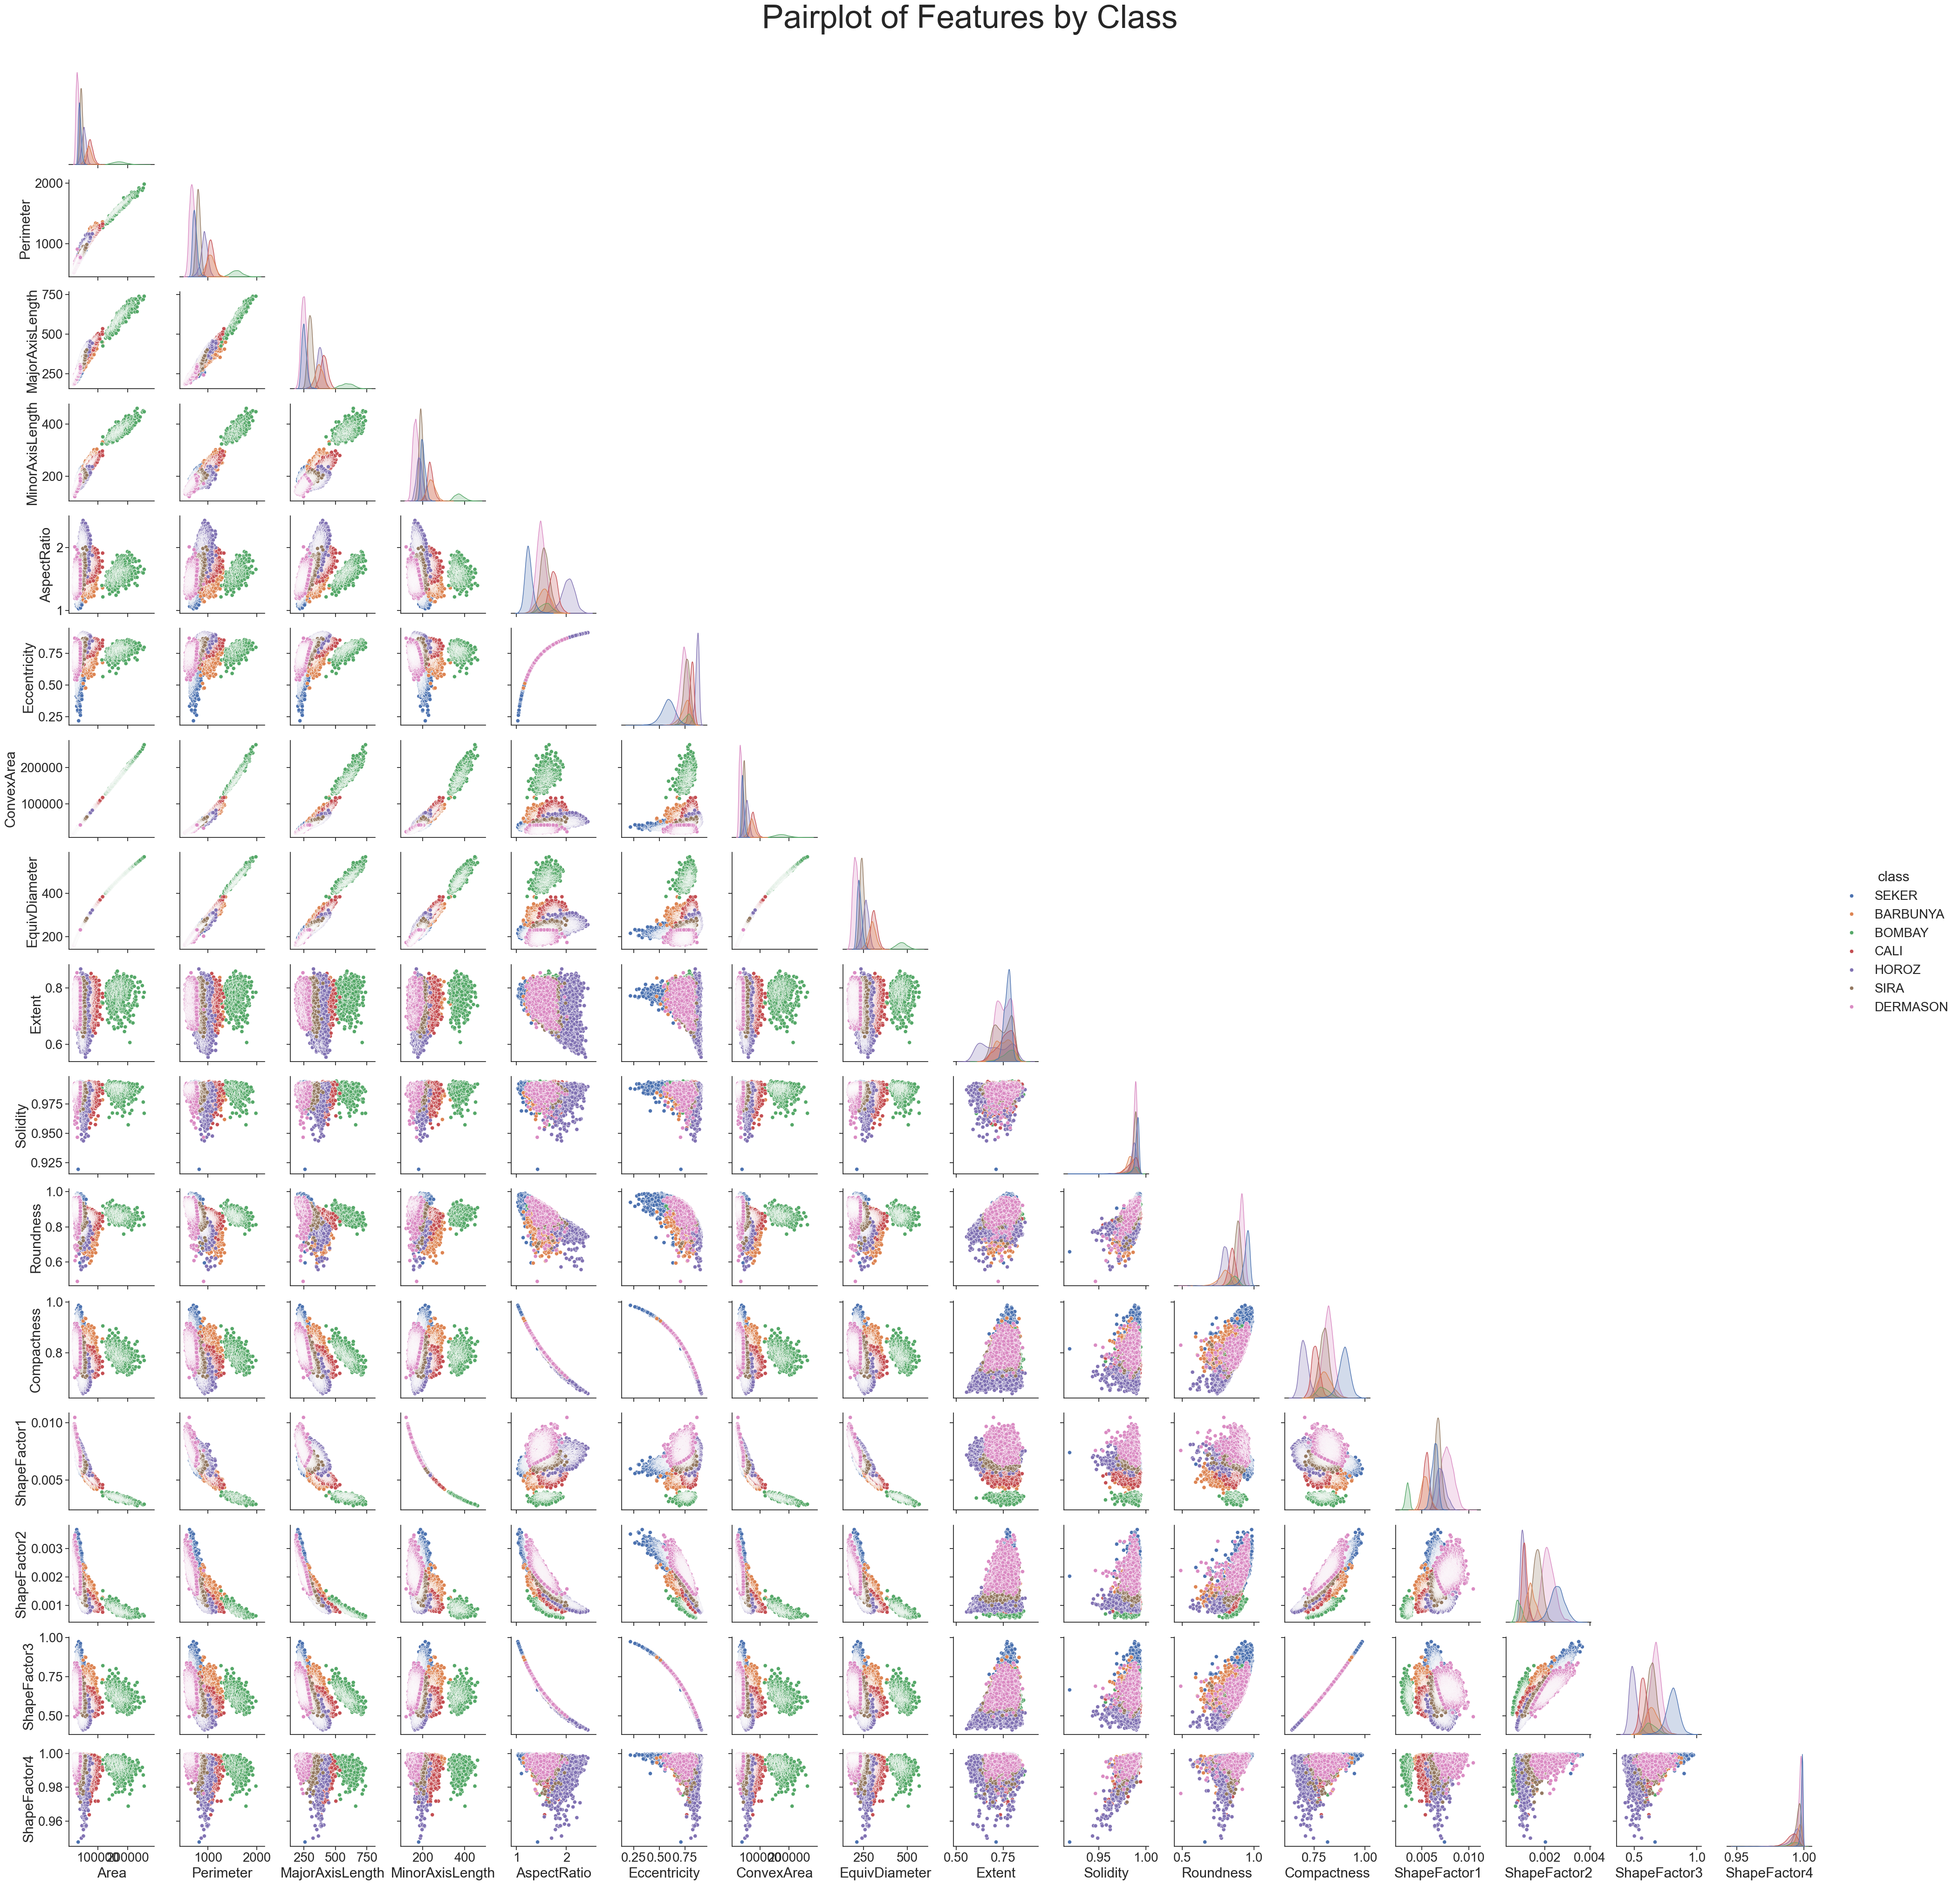

In [7]:
# Pairplot

sns.set(style="ticks", font_scale=1.8)
pair = sns.pairplot(df, hue='class', corner=True)
plt.suptitle('Pairplot of Features by Class', y=1.02, fontsize=50)

plt.show()

The pairplot revealed that the features `Area`, `Perimeter`, and `ShapeFactor1` clearly separate certain bean classes. In particular, `Seker` and `Horoz` are well distinguished. This confirms the suitability of these features for classification tasks.

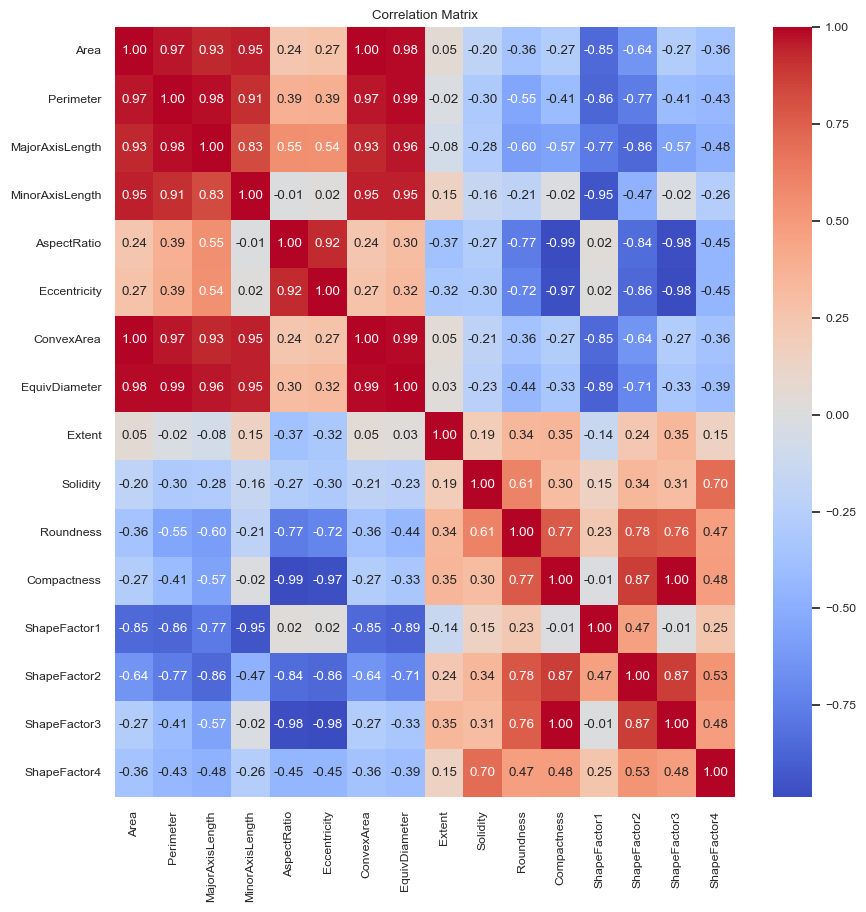

In [13]:
# Correlation matrix
plt.figure(figsize=(10, 10))
corr = df.drop(columns = ['class']).corr()
sns.set(font_scale=0.8)
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

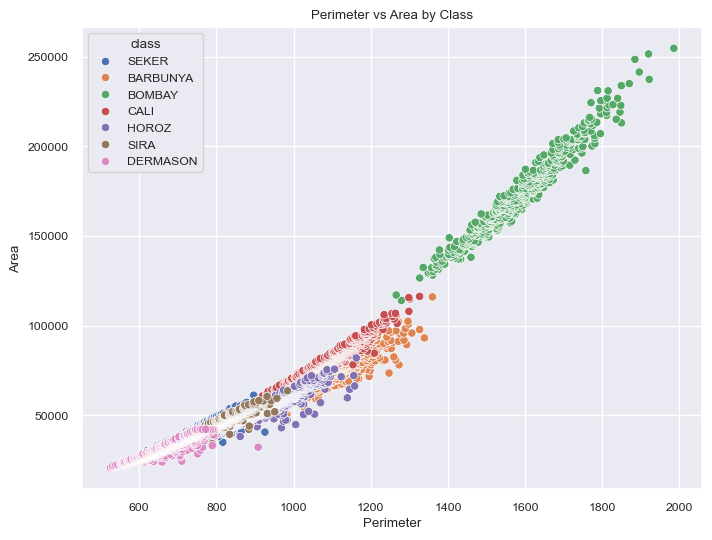

In [14]:
# Scatter plot: Perimeter vs Area
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Perimeter', y='Area', hue='class', palette='deep')
plt.title('Perimeter vs Area by Class')
plt.xlabel('Perimeter')
plt.ylabel('Area')
plt.show()

The scatter plot shows a clear linear relationship between Perimeter and Area, along with partial class-based clustering. These features are suitable for building a linear regression model, which we will test in practice next.

In [15]:
# Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, r2_score, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

def train_and_evaluate_linear_regression(X, y, test_size=0.2, random_state=42):
    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    # Scale features
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train linear regression model
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # Evaluation metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    # Display results
    print(f'R² Score       : {r2 * 100:.2f}%')
    print(f'MAE (Absolute) : {mae:.2f}')
    print(f'MAPE (%)       : {mape * 100:.2f}%')
    print(f'RMSE           : {rmse:.2f}')
    print(f'MSE            : {mse:.2f}')

We developed a universal function train_and_evaluate_linear_regression that automatically performs all the steps of training a linear regression model and calculating key performance metrics. This approach allows for convenient comparison of different feature sets.

In [18]:
# Simple linear
y = df['Area'] # Target variable
X = df[['Perimeter']]
train_and_evaluate_linear_regression(X, y)

R² Score       : 93.47%
MAE (Absolute) : 5465.34
MAPE (%)       : 10.35%
RMSE           : 7797.79
MSE            : 60805604.80


The linear regression model trained to predict `Area` from `Perimeter` achieved an R² score of **93.47%**, indicating that the model explains a significant portion of the variance in the target variable. The error metrics are as follows: **MAE** = 5465.34, **RMSE** = 7797.79, **MAPE** = 10%, and **MSE** = 60,805,604.80. These results confirm that `Perimeter` is a strong predictor of `Area`, making this pair suitable for regression tasks within the dataset.

Although the linear regression model based on `Perimeter` alone achieved good results, there is still room for improvement. To further increase prediction accuracy, we will extend the model to include multiple features and build a multiple linear regression model.

In [19]:
# Multiple Linear Regression using all selected features
# Define the target variable and multiple features
y = df['Area']
X = df[['Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'ConvexArea', 'EquivDiameter']]

# Train and evaluate the multiple linear regression model
train_and_evaluate_linear_regression(X, y)

R² Score       : 99.99%
MAE (Absolute) : 152.87
MAPE (%)       : 0.25%
RMSE           : 279.33
MSE            : 78025.93


Having successfully built and evaluated regression models, we gained a deeper understanding of the relationships between features and the target variable. The final multiple linear regression model achieved an R² score of **99.99%**, with significantly improved error metrics.

Now, we shift our focus to a classification task — predicting the bean variety (`class`). Since `class` is a categorical variable, logistic regression is an appropriate modeling choice. To improve the model’s performance, we will standardize the features before training.

In [20]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Encode the target variable and save class names
encoder = LabelEncoder()
df['class'] = encoder.fit_transform(df['class'])  # Encode class labels
class_labels = encoder.classes_                  # Save original class names

# Define features and target
X = df.drop(columns=['class'])  # Features
y = df['class']                 # Target variable (encoded)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression model
model = LogisticRegression(max_iter=5000,class_weight='balanced')
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)

# Calculate accuracy and classification report
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Create a classification report with class names
class_report_df = pd.DataFrame(
    classification_report(y_test, y_pred, target_names=class_labels, output_dict=True)
).transpose().round(2)

# Display results
print(f'Accuracy: {accuracy * 100:.2f}%')
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Logistic Regression)')
plt.show()
print('\nClassification Report:')
display(class_report_df)


,precision,recall,f1-score,support
BARBUNYA,0.92,0.94,0.93,261.00
BOMBAY,1.00,1.00,1.00,117.00
CALI,0.95,0.94,0.94,317.00
DERMASON,0.94,0.88,0.91,671.00
HOROZ,0.97,0.97,0.97,408.00
SEKER,0.96,0.94,0.95,413.00
SIRA,0.84,0.91,0.87,536.00
accuracy,0.93,0.93,0.93,0.93
macro avg,0.94,0.94,0.94,2723.00
weighted avg,0.93,0.93,0.93,2723.00


## Conclusion

The logistic regression model was trained to classify dry bean varieties and achieved an overall accuracy of 92.62%.
Before training, the features were standardized using StandardScaler, which improved the model’s stability and performance.
Based on the test results, the model demonstrated high precision, recall, and F1-scores, confirming its reliability in solving this classification task.